In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import pearsonr
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv("Augmented_Project_Data_240.csv")

# Replace zeros with mean values (for numeric columns only)
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col] = df[col].replace(0, df[col].mean())

# Round numeric columns to 3 decimal places
for col in numeric_cols:
    df[col] = df[col].round(3)

target_options = {
    "1": "Areal Capacitance (mF/cm2)",
    "2": "Energy Density ( uWh/cm2)",
    "3": "Power Density (mW/cm2)"
}

print("Which value do you want to use as input?")
print("1. Areal Capacitance (mF/cm2)")
print("2. Energy Density ( uWh/cm2)")
print("3. Power Density (mW/cm2)")
user_choice = input("Enter option (1/2/3): ").strip()

if user_choice not in target_options:
    print("Invalid choice. Please run again.")
    exit()

target_col = target_options[user_choice]
print(f"\nYou selected: {target_col}")
print(f"Allowed range: Min = {df[target_col].min()}, Max = {df[target_col].max()}")

try:
    user_value = float(input(f"Enter your desired value for {target_col}: "))
    user_value = round(user_value, 3)
except ValueError:
    print("Invalid number. Please run again.")
    exit()

electrode_choice = input("\nDo you want to use only LIG electrodes? (yes/no): ").strip().lower()
if electrode_choice == "yes":
    df = df[df['Electrode'].str.strip().str.upper() == "LIG"]

# Prepare reverse data
reverse_df = df.copy()
reverse_df = reverse_df.rename(columns={target_col: "Target"})
X = reverse_df[["Electrode", "Electrolyte", "Substrate", "Target"]]
y = reverse_df["Electrolyte Conc.(g/l)"]

categorical_features = ["Electrode", "Electrolyte", "Substrate"]
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
], remainder="passthrough")

models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Compare models
model_scores = {"Model": [], "MAE": [], "R (Correlation)": [], "R²": [], "Accuracy (%)": []}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    r, _ = pearsonr(y_test, y_pred)
    
    # Calculate accuracy as R² * 100 for percentage
    accuracy_percentage = r2 * 100
    
    model_scores["Model"].append(name)
    model_scores["MAE"].append(round(mae, 3))
    model_scores["R (Correlation)"].append(round(r, 3))
    model_scores["R²"].append(round(r2, 3))
    model_scores["Accuracy (%)"].append(round(accuracy_percentage, 2))

scores_df = pd.DataFrame(model_scores)
print("\n📊 Reverse Model Evaluation (80-20 split):")
print(scores_df.to_string(index=False))

# Use best model based on R²
best_model_name = scores_df.loc[scores_df["R²"].idxmax(), "Model"]
print(f"\n✅ Best model selected: {best_model_name}")

best_model = models[best_model_name]
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])
pipeline.fit(X, y)

# Check for exact match in original dataset
exact_matches = df[df[target_col].round(3) == round(user_value, 3)]

if not exact_matches.empty:
    print("\n🔍 Exact matches found in the dataset:")
    print(exact_matches[["Electrode", "Electrolyte", "Substrate", target_col, "Electrolyte Conc.(g/l)"]].to_string(index=False))
else:
    print("\n❌ No exact match found in dataset. Proceeding with prediction...")

# Predict for user-defined target
material_combos = df[["Electrode", "Electrolyte", "Substrate"]].drop_duplicates()
results = []

for _, row in material_combos.iterrows():
    input_row = pd.DataFrame([{
        "Electrode": row["Electrode"],
        "Electrolyte": row["Electrolyte"],
        "Substrate": row["Substrate"],
        "Target": user_value
    }])
    predicted_conc = pipeline.predict(input_row)[0]
    results.append({
        "Electrode": row["Electrode"],
        "Electrolyte": row["Electrolyte"],
        "Substrate": row["Substrate"],
        "Predicted Conc. (g/l)": round(predicted_conc, 2)
    })

result_df = pd.DataFrame(results)
print("\n🔮 Predicted material combinations to achieve your target value:")
print(result_df.sort_values(by="Predicted Conc. (g/l)").head(5).to_string(index=False))


Which value do you want to use as input?
1. Areal Capacitance (mF/cm2)
2. Energy Density ( uWh/cm2)
3. Power Density (mW/cm2)
Enter option (1/2/3): 1

You selected: Areal Capacitance (mF/cm2)
Allowed range: Min = 0.005, Max = 101.93
Enter your desired value for Areal Capacitance (mF/cm2): 90

Do you want to use only LIG electrodes? (yes/no): no

📊 Reverse Model Evaluation (80-20 split):
            Model   MAE  R (Correlation)    R²  Accuracy (%)
    Decision Tree 5.601            0.997 0.995         99.45
    Random Forest 5.171            0.997 0.995         99.46
Gradient Boosting 5.207            0.997 0.995         99.47
          XGBoost 5.046            0.998 0.995         99.53

✅ Best model selected: Decision Tree

❌ No exact match found in dataset. Proceeding with prediction...

🔮 Predicted material combinations to achieve your target value:
Electrode    Electrolyte  Substrate  Predicted Conc. (g/l)
      LIG      PVA/H3PO4  Kapton PI                 329.24
    LIG-C      PVA

In [2]:
# Load your DataFrame (replace with your actual loading method if needed)
df = pd.read_csv("Augmented_Project_Data_240.csv")  # Change to your actual file path

# Select numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Replace all-zero values in numeric columns with NaN
for col in numeric_cols:
    df[col] = df[col].replace(0, np.nan)

# Fill NaN values **only in numeric columns** with their respective column means
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())


# Generate descriptive statistics
desc_stats = df[numeric_cols].describe().T

# Add noise level (equal to Std Dev)
desc_stats["Noise level (Std Dev)"] = desc_stats["std"]

# Rearranging and renaming columns for a clean 9x9 summary
summary_table = desc_stats.loc[:, ["mean", "std", "min", "25%", "50%", "75%", "max", "Noise level (Std Dev)"]]
summary_table.columns = ["Mean", "Std Dev", "Min", "25 %", "50 %", "75 %", "Max", "Noise level (Std Dev)"]

# Round values for readability
summary_table = summary_table.round(3)

# Print full DataFrame without line wrapping
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', None)

print("\nFeature Summary Table with Noise Level:\n")
print(summary_table)




Feature Summary Table with Noise Level:

                                Mean   Std Dev      Min      25 %      50 %       75 %        Max  Noise level (Std Dev)
Electrolyte Conc.(g/l)       177.536    94.296   76.475    89.136   183.844    276.440    345.444                 94.296
Areal Capacitance (mF/cm2)    24.614    25.255    0.005     4.350    20.344     28.657    101.930                 25.255
Current (mA/cm2)               0.526     0.716    0.003     0.068     0.463      0.526      2.808                  0.716
Scan Rate (mV/s)              17.789    27.951    0.100     3.898     8.292     11.228    103.333                 27.951
Energy Density ( uWh/cm2)      4.048     4.818    0.003     0.468     2.768      3.595     17.476                  4.818
Power Density (mW/cm2)         0.616     0.856    0.002     0.074     0.272      0.616      2.591                  0.856
Cyclability(%)                94.649    23.592   73.047    81.736    92.821     97.028    192.398              

In [3]:
import pandas as pd

# dataset is loaded into a DataFrame called 'df'
zero_values = (df == 0).sum()

print(zero_values)


Electrode                     0
Electrolyte                   0
Substrate                     0
Electrolyte Conc.(g/l)        0
Areal Capacitance (mF/cm2)    0
Current (mA/cm2)              0
Scan Rate (mV/s)              0
Energy Density ( uWh/cm2)     0
Power Density (mW/cm2)        0
Cyclability(%)                0
No. of cycles                 0
dtype: int64


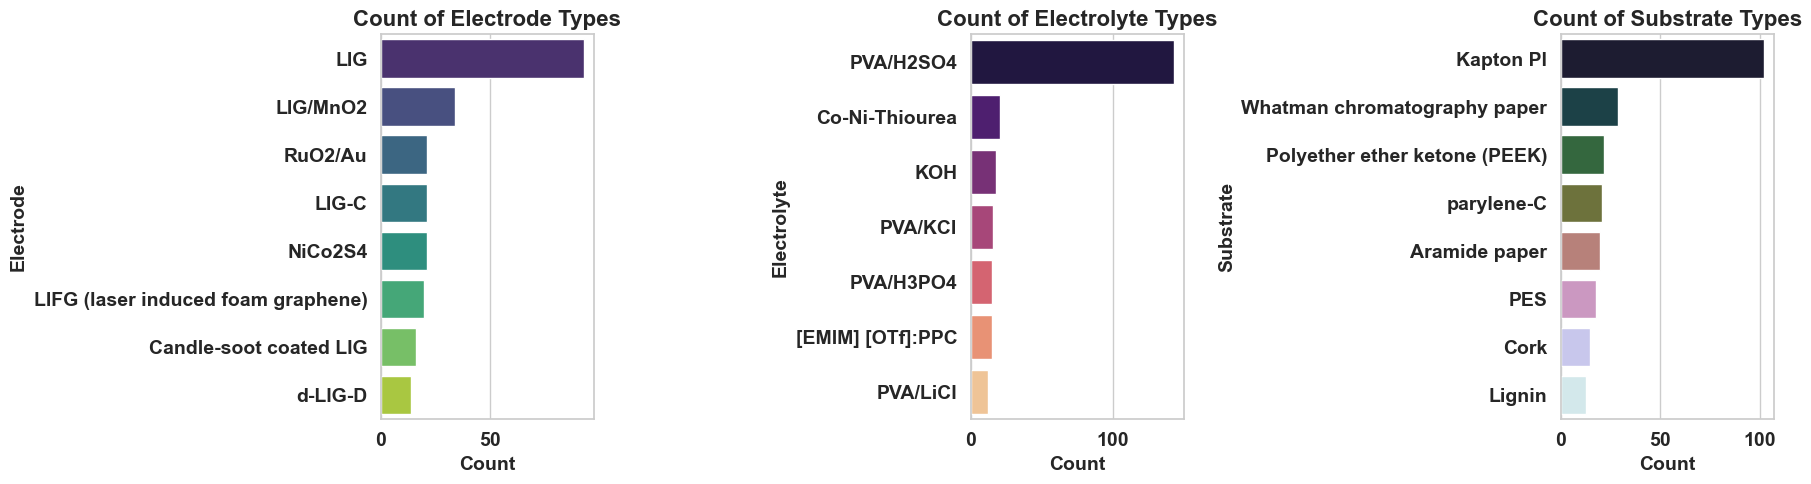

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global font and style
plt.rcParams.update({
    'font.size': 14,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'font.family': 'sans-serif'
})

# Set seaborn style
sns.set(style="whitegrid")
plt.figure(figsize=(18, 5))

# Plot 1: Electrode Count
plt.subplot(1, 3, 1)
sns.countplot(data=df, y="Electrode", order=df["Electrode"].value_counts().index, palette="viridis")
plt.title("Count of Electrode Types", fontsize=16, fontweight='bold')
plt.xlabel("Count", fontsize=14, fontweight='bold')
plt.ylabel("Electrode", fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=14, width=1.5)

# Plot 2: Electrolyte Count
plt.subplot(1, 3, 2)
sns.countplot(data=df, y="Electrolyte", order=df["Electrolyte"].value_counts().index, palette="magma")
plt.title("Count of Electrolyte Types", fontsize=16, fontweight='bold')
plt.xlabel("Count", fontsize=14, fontweight='bold')
plt.ylabel("Electrolyte", fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=14, width=1.5)

# Plot 3: Substrate Count
plt.subplot(1, 3, 3)
sns.countplot(data=df, y="Substrate", order=df["Substrate"].value_counts().index, palette="cubehelix")
plt.title("Count of Substrate Types", fontsize=16, fontweight='bold')
plt.xlabel("Count", fontsize=14, fontweight='bold')
plt.ylabel("Substrate", fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=14, width=1.5)

# Adjust layout and show
plt.tight_layout()
plt.show()


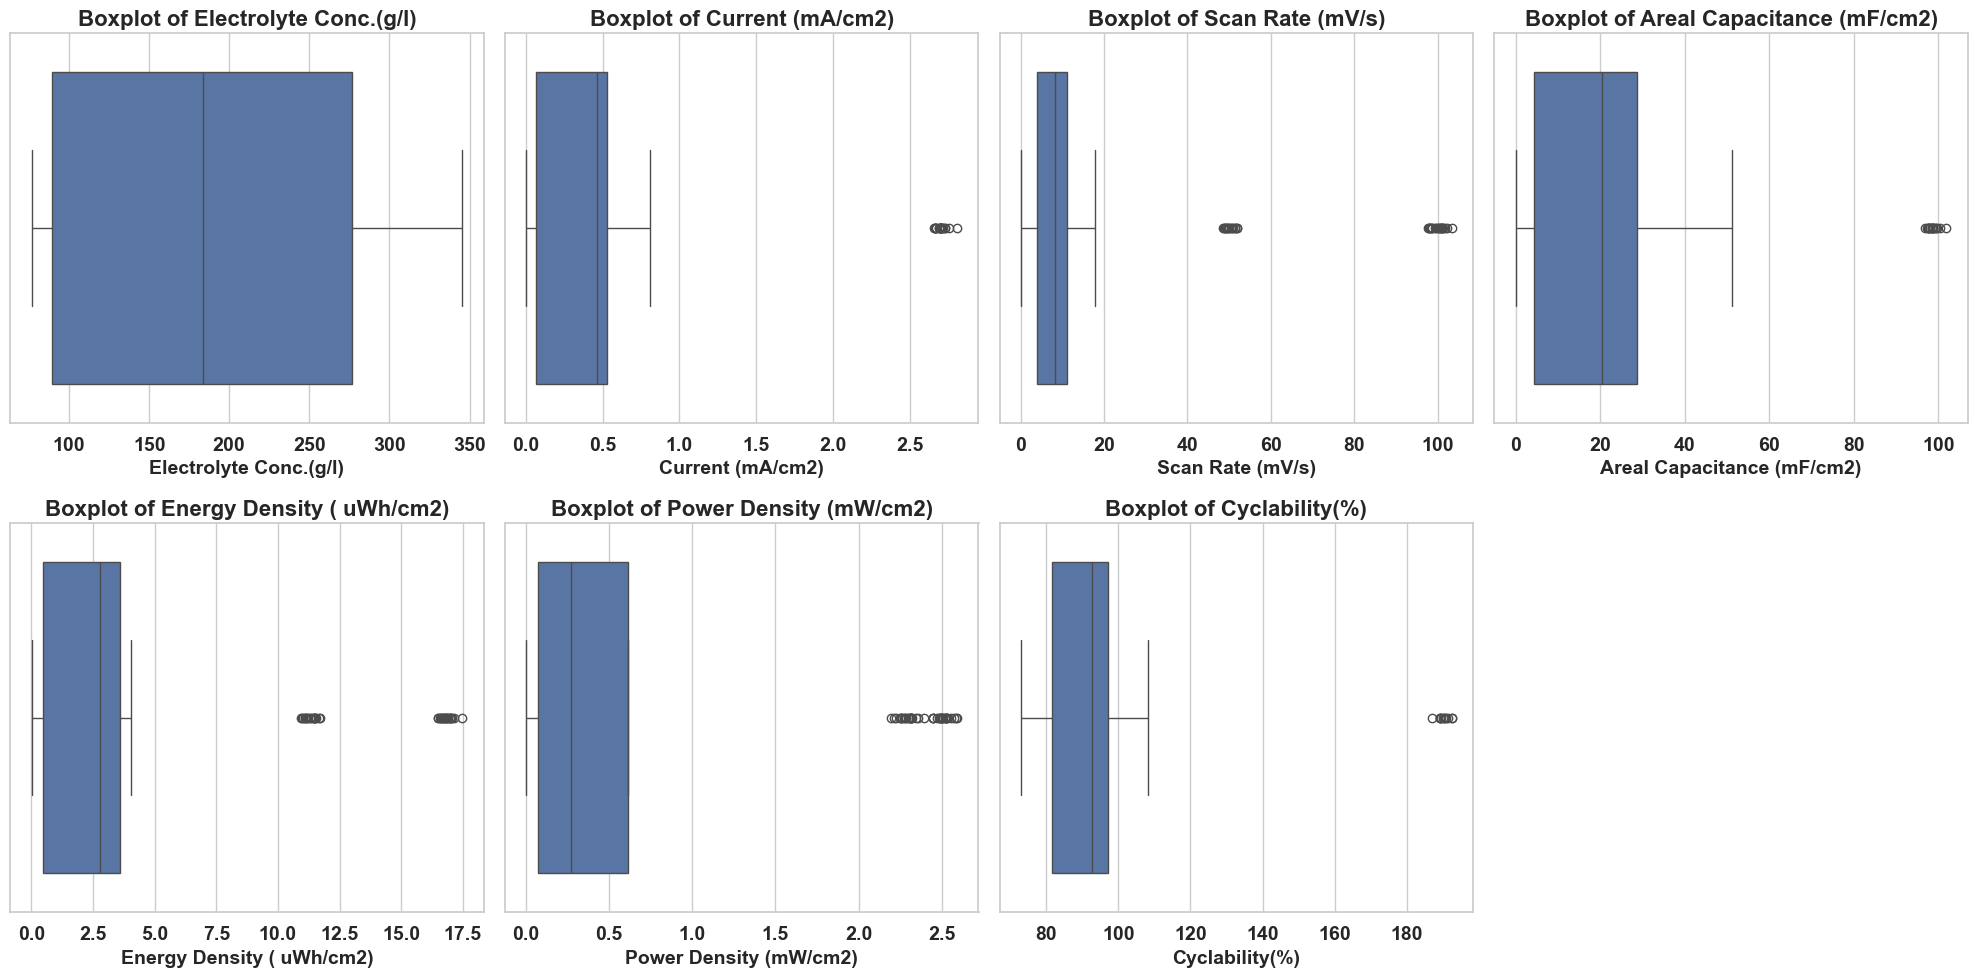

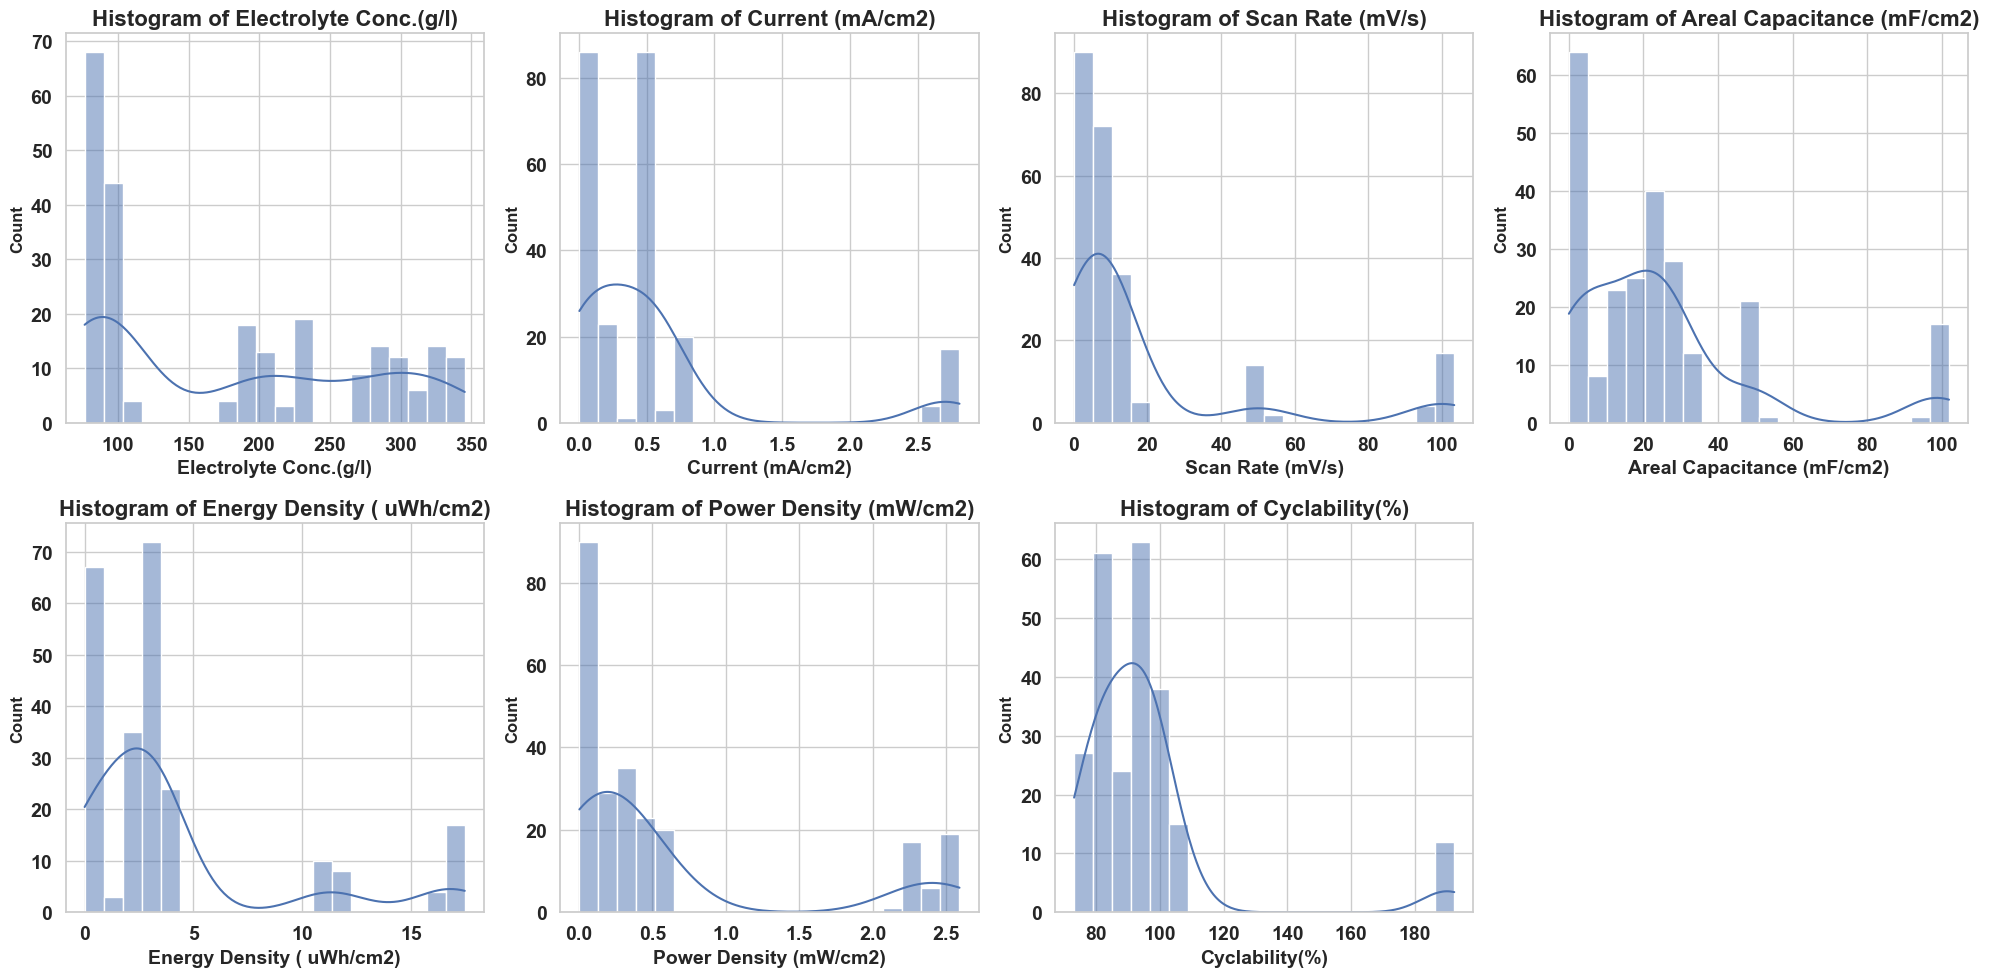

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the plotting style
sns.set(style="whitegrid")

# Update global font parameters
plt.rcParams.update({
    'font.size': 14,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'font.family': 'sans-serif'
})

# List of columns to plot
columns_to_plot = ['Electrolyte Conc.(g/l)', 'Current (mA/cm2)', 'Scan Rate (mV/s)',
                   'Areal Capacitance (mF/cm2)', 'Energy Density ( uWh/cm2)', 
                   'Power Density (mW/cm2)', 'Cyclability(%)']

# ----------- Boxplots -----------
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(columns_to_plot):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}', fontsize=16, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=14, fontweight='bold')
    axes[i].tick_params(axis='both', which='major', labelsize=14, width=1.5)

# Hide the 8th subplot if not used
if len(columns_to_plot) < len(axes):
    axes[len(columns_to_plot)].axis('off')

plt.tight_layout()
plt.show()

# ----------- Histograms -----------
fig_hist, axes_hist = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes_hist = axes_hist.flatten()

for i, col in enumerate(columns_to_plot):
    sns.histplot(df[col], kde=True, ax=axes_hist[i], bins=20)
    axes_hist[i].set_title(f'Histogram of {col}', fontsize=16, fontweight='bold')
    axes_hist[i].set_xlabel(col, fontsize=14, fontweight='bold')
    axes_hist[i].tick_params(axis='both', which='major', labelsize=14, width=1.5)

# Hide the 8th subplot if not used
if len(columns_to_plot) < len(axes_hist):
    axes_hist[len(columns_to_plot)].axis('off')

plt.tight_layout()
plt.show()


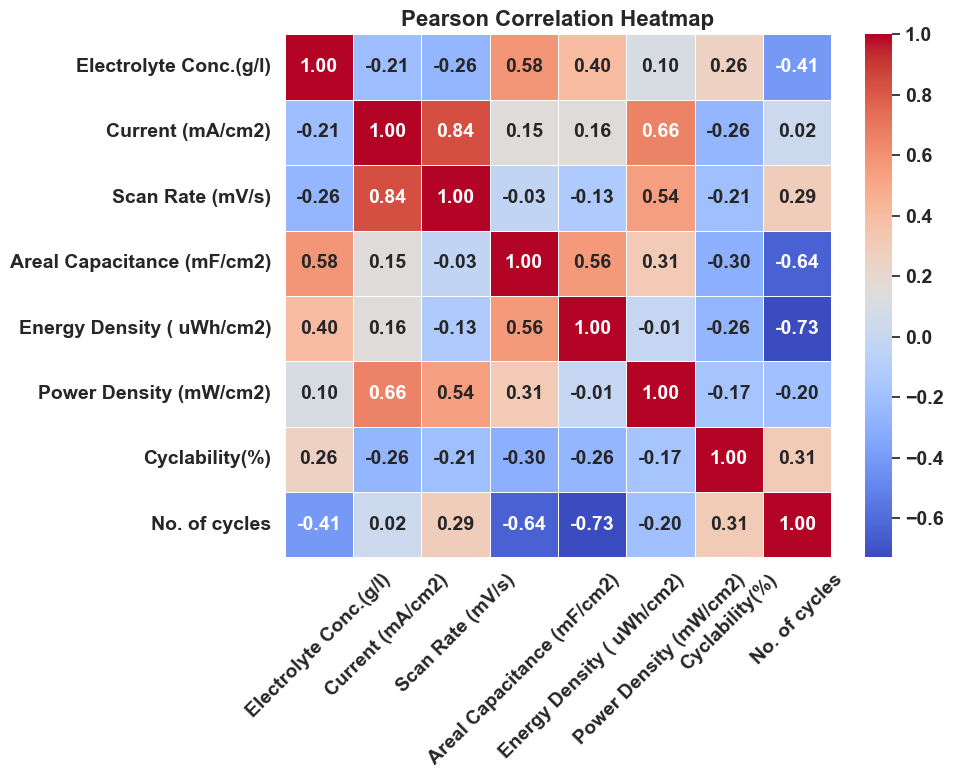

In [6]:
# Select only the numeric columns for correlation
numeric_cols = ['Electrolyte Conc.(g/l)', 'Current (mA/cm2)', 'Scan Rate (mV/s)',
                'Areal Capacitance (mF/cm2)', 'Energy Density ( uWh/cm2)',
                'Power Density (mW/cm2)', 'Cyclability(%)', 'No. of cycles']

# Compute Pearson correlation matrix
corr_matrix = df[numeric_cols].corr(method='pearson')

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Pearson Correlation Heatmap')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
